**SO I AM IMPLEMENTING THE BACKPROPAGATION CODE WITHOUT USING KERAS**

In [56]:
import numpy as np
import pandas as pd

Epoch ------------------------------------  1 Loss -----------------------  0.6970005747766173
Epoch ------------------------------------  2 Loss -----------------------  0.6969986672879349
Epoch ------------------------------------  3 Loss -----------------------  0.6969967607537533
Epoch ------------------------------------  4 Loss -----------------------  0.6969948551735786
Epoch ------------------------------------  5 Loss -----------------------  0.696992950546918


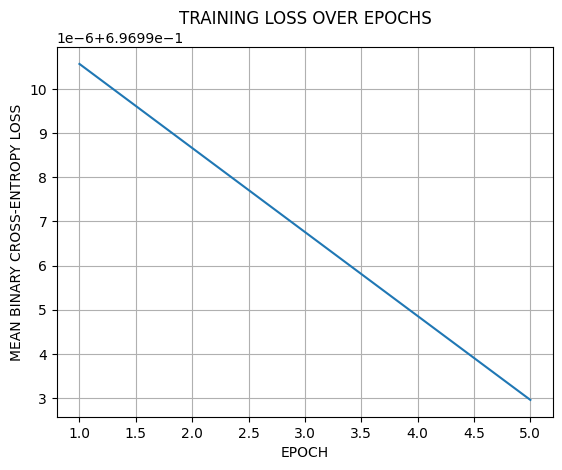

In [57]:
paramter = initialize_parameter([2,2,1])

epochs = 5
learning_rate = 0.0001

all_epoch_losses = []

for i in range(epochs):
    epoch_loss = []

    for j in range(dataset.shape[0]):
        x = dataset[["CGPA", "PROFILE_SCORE"]].values[j].reshape(2,1)
        y = dataset[["PLACED"]].values[j][0]

        y_hat_val, A1_val = l_layer_forward(x, paramter)

        epsilon = 1e-10
        y_hat_clipped = np.clip(y_hat_val, epsilon, 1 - epsilon)
        current_loss = -(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
        epoch_loss.append(current_loss[0][0])

        update_parameters(paramter, y, y_hat_val, A1_val, x, learning_rate)

    mean_epoch_loss = np.array(epoch_loss).mean()
    all_epoch_losses.append(mean_epoch_loss)
    print("Epoch ------------------------------------ ", i+1, "Loss ----------------------- ", mean_epoch_loss)

import matplotlib.pyplot as plt

plt.plot(range(1, epochs + 1), all_epoch_losses)
plt.xlabel("EPOCH")
plt.ylabel("MEAN BINARY CROSS-ENTROPY LOSS")
plt.title("TRAINING LOSS OVER EPOCHS")
plt.grid(True)
plt.show()